# QSVT で周期 Poisson 方程式を解く

このノートブックは PR 549 の周期 Poisson 方程式の例を、現在の
`PeriodicShiftLCU`、`qmc.periodic_shift_lcu_block_encoding`、`qmc.qsvt`
を使って書き直したものです。1 次元と 2 次元について、次の流れを確認します。

1. 周期差分 Laplacian を周期シフトの線形結合として記述する。
2. その記述から block encoding を生成し、leading block を検証する。
3. 右辺を振幅 encoding し、QSVT の逆数近似を適用する。
4. signal qubit がすべて 0 の成分を取り出し、古典的な擬似逆行列の解と比較する。

例を小さくしているのは、`Operator` と `Statevector` による厳密 simulation を
行うためです。大規模な問題では、これらの厳密検証を sampling や resource estimate
に置き換える必要があります。

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import Operator, Statevector

import qamomile.circuit as qmc
from qamomile.circuit.serialization import deserialize, serialize
from qamomile.linalg import PeriodicShiftLCU
from qamomile.qiskit import QiskitTranspiler

## QSVT 位相

下の位相列は `1/x` の有界多項式近似を作るために一度だけ生成したものです。
ここでは `kappa=2`、`epsilon=0.2` で生成した pyqsp の `Wx` 位相を、
`qmc.qsvt` が使う projector rotation

$$
R(\phi)=\exp\left(i\phi(2\Pi-I)\right)
$$

の規約へ変換した値を埋め込んでいます。そのため、このノートブックの実行には
pyqsp は必要ありません。`kappa=2` は、正規化後の非零特異値が
$|x|\geq 1/2$ にある今回の入力成分を対象にしています。別の近似多項式を使う場合は、
その位相合成を別途行い、raw `Wx` 位相をそのまま渡さないでください。

In [2]:
def convert_wx_to_qsvt(wx_phases):
    """Convert pyqsp Wx phases to Qamomile projector phases.

    Args:
        wx_phases (np.ndarray): Phase sequence returned for the Wx convention.

    Returns:
        np.ndarray: Phases for ``qmc.qsvt`` projector rotations.
    """
    wx_phases = np.asarray(wx_phases, dtype=float)
    degree = len(wx_phases) - 1
    phases = np.zeros_like(wx_phases)
    phases[0] = wx_phases[0] + (2 * degree - 1) * np.pi / 4
    for index in range(1, degree):
        phases[index] = wx_phases[index] - np.pi / 2
    phases[degree] = wx_phases[degree] - np.pi / 4
    return (phases + np.pi) % (2 * np.pi) - np.pi


# The embedded values below are convert_wx_to_qsvt(phi_wx).

In [3]:
INVERSE_PHASES = np.array(
    [
        -0.7853598681349858,
        -1.5708917154793360,
        -1.5699824631522350,
        -1.5755263114663982,
        -1.5512057973624391,
        -1.6323187141296431,
        -1.4193553088198976,
        -1.8626779548687709,
        -1.1491617378849364,
        -1.1491617378849353,
        -1.8626779548687709,
        -1.4193553088199014,
        -1.6323187141296450,
        -1.5512057973624398,
        -1.5755263114664002,
        -1.5699824631522352,
        -1.5708917154793376,
        -0.7853598681349871,
    ],
    dtype=float,
)

print("QSVT phase count:", len(INVERSE_PHASES))

QSVT phase count: 18


## 共通の補助関数

周期 Laplacian は定数 vector を零空間に持つので、右辺は平均 0 でなければ
なりません。ここでは明示的に平均を引き、古典解には `np.linalg.pinv` を使います。

In [4]:
def periodic_laplacian_1d(n, length=1.0):
    """Build a one-dimensional periodic finite-difference Laplacian.

    Args:
        n (int): Number of grid points.
        length (float): Periodic interval length.

    Returns:
        tuple[np.ndarray, np.ndarray, float]: Matrix, grid points, and spacing.
    """
    spacing = length / n
    matrix = np.zeros((n, n), dtype=float)
    for index in range(n):
        matrix[index, index] = -2.0
        matrix[index, (index + 1) % n] += 1.0
        matrix[index, (index - 1) % n] += 1.0
    return matrix / spacing**2, np.arange(n) * spacing, spacing


def normalize(vector):
    """Normalize a nonzero vector.

    Args:
        vector (np.ndarray): Input vector.

    Returns:
        np.ndarray: Normalized vector.

    Raises:
        ValueError: If the input vector is zero.
    """
    vector = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(vector)
    if norm == 0:
        raise ValueError("Cannot normalize the zero vector.")
    return vector / norm


def zero_mean(vector):
    """Project a vector onto the zero-mean subspace.

    Args:
        vector (np.ndarray): Periodic Poisson right-hand side.

    Returns:
        np.ndarray: Zero-mean vector.
    """
    vector = np.asarray(vector, dtype=float)
    return vector - np.mean(vector)


def fidelity(actual, expected):
    """Compute the squared overlap of two nonzero vectors.

    Args:
        actual (np.ndarray): First vector.
        expected (np.ndarray): Second vector.

    Returns:
        float: Squared normalized overlap.
    """
    actual = np.asarray(actual, dtype=complex)
    expected = np.asarray(expected, dtype=complex)
    return float(
        abs(np.vdot(actual, expected)) ** 2
        / (np.vdot(actual, actual).real * np.vdot(expected, expected).real)
    )


@qmc.qkernel
def apply_block_encoding(
    encoding: qmc.LCUBlockEncoding,
) -> tuple[qmc.Vector[qmc.Bit], qmc.Vector[qmc.Bit]]:
    """Apply a statically supplied LCU block encoding.

    Args:
        encoding (qmc.LCUBlockEncoding): Exact LCU block encoding descriptor.

    Returns:
        tuple[qmc.Vector[qmc.Bit], qmc.Vector[qmc.Bit]]: Measured signal and
            system registers.
    """
    # Allocate system first so its basis index occupies the low Qiskit bits.
    system = qmc.qubit_array(encoding.num_system_qubits, "system")
    signal = qmc.qubit_array(encoding.num_signal_qubits, "signal")
    signal, system = encoding.unitary(signal, system)
    return qmc.measure(signal), qmc.measure(system)


def make_qsvt_solver(rhs):
    """Build a serializable QSVT solver for one concrete source state.

    Args:
        rhs (np.ndarray): Normalized real source vector.

    Returns:
        qmc.QKernel: Kernel whose encoding and phases remain statically bindable.

    Raises:
        ValueError: If the source length is not a positive power of two.
    """
    rhs = normalize(rhs)
    num_system = int(math.log2(rhs.size))
    if 1 << num_system != rhs.size:
        raise ValueError("The source length must be a positive power of two.")

    @qmc.qkernel
    def solve(
        encoding: qmc.LCUBlockEncoding,
        phases: qmc.Vector[qmc.Float],
    ) -> tuple[qmc.Vector[qmc.Bit], qmc.Vector[qmc.Bit]]:
        """Prepare the source and apply a statically supplied QSVT sequence.

        Args:
            encoding (qmc.LCUBlockEncoding): Exact LCU block encoding descriptor.
            phases (qmc.Vector[qmc.Float]): Projector phases in radians.

        Returns:
            tuple[qmc.Vector[qmc.Bit], qmc.Vector[qmc.Bit]]: Measured signal and
                system registers.
        """
        system = qmc.qubit_array(num_system, "system")
        signal = qmc.qubit_array(encoding.num_signal_qubits, "signal")
        system = qmc.amplitude_encoding(system, rhs)
        signal, system = qmc.qsvt(signal, system, phases, encoding)
        return qmc.measure(signal), qmc.measure(system)

    return solve


transpiler = QiskitTranspiler()


def encoded_leading_block(encoding):
    """Extract the normalized all-zero-signal leading block.

    Args:
        encoding (qmc.LCUBlockEncoding): Block encoding to inspect.

    Returns:
        np.ndarray: Matrix encoded in the all-zero signal block.
    """
    circuit = transpiler.to_circuit(
        apply_block_encoding,
        bindings={"encoding": encoding},
    ).remove_final_measurements(inplace=False)
    system_size = 1 << encoding.num_system_qubits
    return Operator(circuit).data[:system_size, :system_size]


def run_serialized_solver(rhs, encoding):
    """Serialize, deserialize, bind, and simulate one QSVT solver.

    Args:
        rhs (np.ndarray): Normalized source vector.
        encoding (qmc.LCUBlockEncoding): Block encoding bound after deserialization.

    Returns:
        tuple[np.ndarray, float]: Real part of the postselected system vector
            and its success probability.
    """
    payload = serialize(make_qsvt_solver(rhs))
    received_solver = deserialize(payload)
    circuit = transpiler.to_circuit(
        received_solver,
        bindings={
            "encoding": encoding,
            "phases": INVERSE_PHASES.tolist(),
        },
    ).remove_final_measurements(inplace=False)
    state = Statevector.from_instruction(circuit).data
    system_size = len(rhs)
    projected = state[:system_size]
    probability = float(np.vdot(projected, projected).real)
    return projected.real, probability


def rescale_solution(candidate, matrix, rhs):
    """Fit the unnormalized postselected vector to the linear system.

    Args:
        candidate (np.ndarray): Postselected QSVT system vector.
        matrix (np.ndarray): Classical linear-system matrix.
        rhs (np.ndarray): Classical right-hand side.

    Returns:
        np.ndarray: Least-squares-rescaled candidate solution.
    """
    image = matrix @ candidate
    scale = np.vdot(image, rhs) / np.vdot(image, image)
    return scale * candidate

## 1 次元周期 Poisson 方程式

格子間隔を $h$ とすると、周期差分 Laplacian は

$$
A_{1D}=\frac{1}{h^2}\left(-2I+S_{+}+S_{-}\right)
$$

です。これは 3 項の `PeriodicShiftLCU` としてそのまま記述できます。
以前のノートブックにあった controlled increment/decrement、PREPARE、SELECT、
UNPREPARE の qkernel は不要です。

In [5]:
n_1d = 8
A1, x1, h1 = periodic_laplacian_1d(n_1d)

# A Fourier mode is automatically compatible with the periodic nullspace.
b1 = zero_mean(np.cos(4.0 * np.pi * x1))
normalized_b1 = normalize(b1)
classical_u1 = np.linalg.pinv(A1) @ normalized_b1

lcu_1d = PeriodicShiftLCU.from_coefficients(
    {
        -1: 1.0 / h1**2,
        0: -2.0 / h1**2,
        1: 1.0 / h1**2,
    },
    register_sizes=(int(math.log2(n_1d)),),
)
encoding_1d = qmc.periodic_shift_lcu_block_encoding(lcu_1d)

print("1D normalization:", encoding_1d.normalization)
print("1D signal qubits:", encoding_1d.num_signal_qubits)

1D normalization: 256.0
1D signal qubits: 2


### 1D block encoding の leading block を検証する

descriptor の規約は

$$
(\langle 0|_{\mathrm{signal}}\otimes I)U
(|0\rangle_{\mathrm{signal}}\otimes I)
=A/\alpha
$$

で、`encoding.normalization` が $\alpha$ です。

In [6]:
leading_1d = encoded_leading_block(encoding_1d)
reconstructed_A1 = encoding_1d.normalization * leading_1d

print(
    "1D leading block matches A:",
    np.allclose(reconstructed_A1, A1, atol=1e-8),
)
print("1D maximum block error:", np.max(np.abs(reconstructed_A1 - A1)))

1D leading block matches A: True
1D maximum block error: 4.690675612811105e-13


### 1D QSVT

QSVT 本体は `qmc.qsvt(signal, system, phases, encoding)` の 1 行です。
次の helper は tracing 済み kernel を serialize してから deserialize し、
その後に block encoding と位相を bind しています。したがって、送信側は
`PeriodicShiftLCUBlockEncoding` の具体値を tracing 時に知る必要がありません。
元の notebook と同じ位相変換規約に従い、all-zero signal へ射影した振幅の
実部を逆数多項式の出力として取り出します。postselection 確率は射影した複素
振幅全体の norm から計算しています。

`qmc.amplitude_encoding` の角度合成には tracing 時に具体的な右辺が必要なので、
この例では右辺だけを `make_qsvt_solver` の closure に固定しています。block
encoding descriptor と phases は kernel argument のままであり、global に
capture していません。入力状態を別回路で準備済みなら、QSVT 部分は quantum
register を受け取るさらに一般的な template に分離できます。

In [7]:
projected_1d, success_probability_1d = run_serialized_solver(
    normalized_b1,
    encoding_1d,
)
qsvt_u1 = rescale_solution(projected_1d, A1, normalized_b1)

print("1D postselection probability:", success_probability_1d)
print("1D fidelity:", fidelity(qsvt_u1, classical_u1))
print("1D residual norm:", np.linalg.norm(A1 @ qsvt_u1 - normalized_b1))
print("1D maximum solution error:", np.max(np.abs(qsvt_u1 - classical_u1)))

1D postselection probability: 0.7163046164654492
1D fidelity: 1.0
1D residual norm: 2.256249856250387e-15
1D maximum solution error: 2.3007351930004737e-17


この右辺は 1 つの Fourier eigenspace に含まれるため、QSVT 解と擬似逆行列の
解は global phase と scale を除いて一致します。複数の固有値成分を含む例は
次の 2D 問題で確認します。

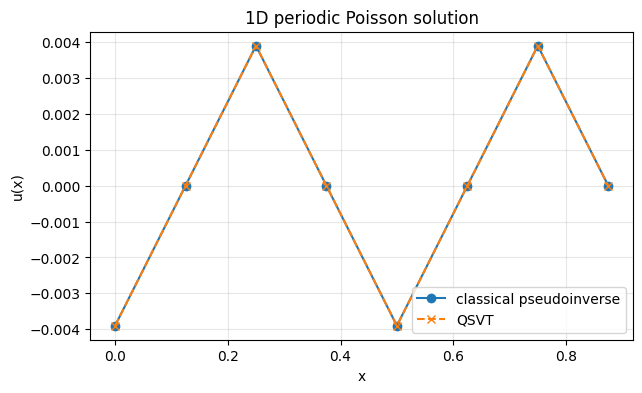

In [8]:
fig, axis = plt.subplots(figsize=(7, 4))
axis.plot(x1, classical_u1.real, "o-", label="classical pseudoinverse")
axis.plot(x1, qsvt_u1.real, "x--", label="QSVT")
axis.set_xlabel("x")
axis.set_ylabel("u(x)")
axis.set_title("1D periodic Poisson solution")
axis.legend()
axis.grid(alpha=0.3)
plt.show()

## 2 次元周期 Poisson 方程式

2D Laplacian は Kronecker 和

$$
A_{2D}=A_{1D}\otimes I+I\otimes A_{1D}
$$

であり、周期シフト LCU では 5 項だけです。offset tuple の第 1、第 2 成分が
それぞれ 2 つの軸 register のシフトを表します。

In [9]:
n_2d = 4
A_axis, axis_grid, h2 = periodic_laplacian_1d(n_2d)
identity_axis = np.eye(n_2d)
A2 = np.kron(A_axis, identity_axis) + np.kron(identity_axis, A_axis)
X2, Y2 = np.meshgrid(axis_grid, axis_grid, indexing="ij")

# The two terms belong to different nonzero Laplacian eigenspaces.
b2_grid = np.cos(4.0 * np.pi * X2) + 0.2 * np.cos(4.0 * np.pi * X2) * np.cos(
    2.0 * np.pi * Y2
)
# Fortran order maps the first array axis to PeriodicShiftLCU axis zero.
b2 = zero_mean(b2_grid.flatten(order="F"))
normalized_b2 = normalize(b2)
classical_u2 = np.linalg.pinv(A2) @ normalized_b2

axis_qubits = int(math.log2(n_2d))
lcu_2d = PeriodicShiftLCU.from_coefficients(
    {
        (0, 0): -4.0 / h2**2,
        (-1, 0): 1.0 / h2**2,
        (1, 0): 1.0 / h2**2,
        (0, -1): 1.0 / h2**2,
        (0, 1): 1.0 / h2**2,
    },
    register_sizes=(axis_qubits, axis_qubits),
)
encoding_2d = qmc.periodic_shift_lcu_block_encoding(lcu_2d)

print("2D normalization:", encoding_2d.normalization)
print("2D signal qubits:", encoding_2d.num_signal_qubits)

2D normalization: 128.0
2D signal qubits: 3


### 2D block encoding の leading block を検証する

In [10]:
leading_2d = encoded_leading_block(encoding_2d)
reconstructed_A2 = encoding_2d.normalization * leading_2d

print(
    "2D leading block matches A:",
    np.allclose(reconstructed_A2, A2, atol=1e-8),
)
print("2D maximum block error:", np.max(np.abs(reconstructed_A2 - A2)))

2D leading block matches A: True
2D maximum block error: 8.249416550420326e-13


### 2D QSVT と古典解の比較

1D とまったく同じ serialized kernel の形を使えます。違うのは bind する
descriptor と state-preparation data だけであり、2D 専用の QSVT qkernel は
必要ありません。

In [11]:
projected_2d, success_probability_2d = run_serialized_solver(
    normalized_b2,
    encoding_2d,
)
qsvt_u2 = rescale_solution(projected_2d, A2, normalized_b2)

print("2D postselection probability:", success_probability_2d)
print("2D fidelity:", fidelity(qsvt_u2, classical_u2))
print("2D residual norm:", np.linalg.norm(A2 @ qsvt_u2 - normalized_b2))
print("2D maximum solution error:", np.max(np.abs(qsvt_u2 - classical_u2)))

2D postselection probability: 0.7186549375905248
2D fidelity: 0.9999433528702758
2D residual norm: 0.01115658145588575
2D maximum solution error: 4.719996717093703e-05


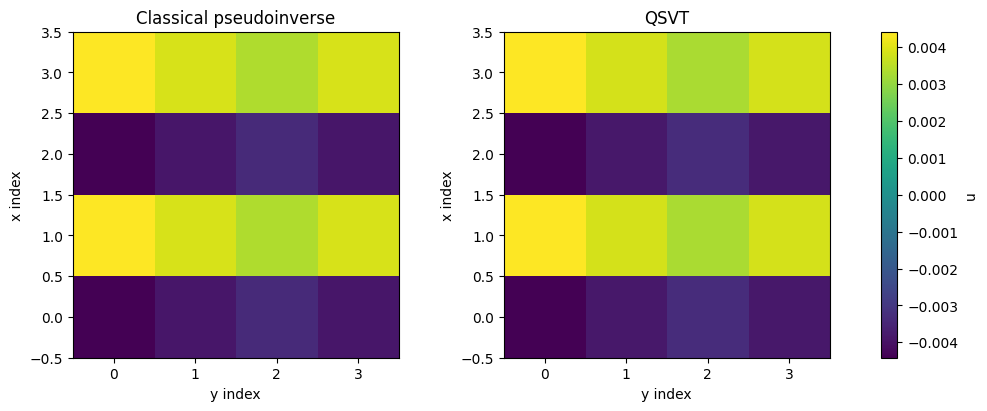

In [12]:
classical_grid = classical_u2.real.reshape(n_2d, n_2d, order="F")
qsvt_grid = qsvt_u2.real.reshape(n_2d, n_2d, order="F")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
vmin = min(classical_grid.min(), qsvt_grid.min())
vmax = max(classical_grid.max(), qsvt_grid.max())

classical_image = axes[0].imshow(
    classical_grid,
    origin="lower",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title("Classical pseudoinverse")
axes[0].set_xlabel("y index")
axes[0].set_ylabel("x index")

axes[1].imshow(
    qsvt_grid,
    origin="lower",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_title("QSVT")
axes[1].set_xlabel("y index")
axes[1].set_ylabel("x index")
fig.colorbar(classical_image, ax=axes, label="u")
plt.show()

## 何が簡単になったか

PR 549 の手書き実装と比べると、次の部分を notebook 側で実装する必要が
なくなりました。

| 以前 notebook に必要だった処理 | 現在使う API |
|---|---|
| 1D/2D の controlled cyclic shift | `PeriodicShiftLCU` の offset |
| LCU の PREPARE / SELECT / UNPREPARE | `qmc.periodic_shift_lcu_block_encoding` |
| block encoding の逆回路 | descriptor の `unitary` を `qmc.qsvt` が使用 |
| all-zero signal projector の補助 qubit と multi-control gate | `qmc.qsvt` 内部 |
| 位相ごとの `U` / `U†` の交互適用 | `qmc.qsvt` |
| 位相数が偶数か奇数かによる別 qkernel | `qmc.qsvt` |
| `theta`、`half_theta`、`neg_half_theta`、`num_pairs` | 変換済み `phases` だけ |
| 1D/2D 専用 QSVT factory | 共通の `make_qsvt_solver` |

block encoding は kernel の static slot、phases は通常の kernel 引数として
未確定のまま残るため、kernel の serialize 後、別 process で deserialize してから
どちらも bind できます。具体的な descriptor を module global に capture する
必要はありません。

この notebook の埋め込み位相は短い説明用の近似です。精度を上げる場合は、
対象行列の正規化後の singular-value domain と必要精度に合わせて逆数多項式を
合成し直してください。